# Which satellites passed over India, and along what path?

**Inputs**
- `TLE_FILE`: element sets, for example the file written by `01_fetch_tle.ipynb` or any Space-Track 3LE file.
  Every satellite in the file is analysed unless `ONLY_NORAD` lists a subset.
- `WINDOWS_FILE`: a text file with two columns, start and end, one time window per row. Times without a time zone
  are UTC; `2026-10-07T05:30:00+05:30` style times are converted. Lines starting with `#` are ignored.
- `DATA_DIR`: India's boundaries, states, cities and the map background (see `data/SOURCES.md`).

**"Over India"** means the sub-satellite point (the ground point directly below the satellite) lies inside India's
boundary, mainland or islands. India's official boundary is used by default; check (c) repeats everything with the
de facto boundary.

**Method.** SGP4 (Skyfield) → WGS84 sub-satellite point every 10 s → 1 s re-sampling near India → exact border
crossings by intersecting the track with the boundary polygon → states, towns, timings → map, timeline, CSV,
GeoJSON and CZML. For each window, each satellite uses the element set whose epoch is nearest the window's middle.

**Outputs** go to `outputs/<window>/`, one folder per window, plus `outputs/summary.csv` across all windows.

Requirements: Python ≥ 3.9, `pip install skyfield shapely pandas matplotlib`.

In [1]:
import json
import math
import os
import warnings
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import shapely
from shapely.geometry import LineString, Point, shape
import matplotlib.pyplot as plt
from matplotlib import patheffects
from matplotlib.lines import Line2D
from IPython.display import Markdown, display
import sgp4
import skyfield
from skyfield.api import EarthSatellite, load, wgs84
from skyfield.framelib import itrs


# ---- inputs ------------------------------------------------------------------
TLE_FILE = "tle/satellites.tle"
WINDOWS_FILE = "time_windows.txt"
DATA_DIR = "data"
ONLY_NORAD = None            # e.g. [61735, 64876] to analyse a subset of the TLE file

BOUNDARY = "official"        # "official" = India's own map; "defacto" = line of control
COARSE_STEP_S = 10           # whole-window sampling: maps and exports
FINE_STEP_S = 1              # sampling near India: exact border crossings
CITY_RADIUS_KM = 50          # towns within this distance of the ground track are listed
MAX_TLE_GAP_DAYS = 3.0       # warn if an element set's epoch is further than this from a window
RUN_CHECKS = True            # the three cross-checks in each window (adds a few seconds)
OUT_ROOT = "outputs"

IST = timezone(timedelta(hours=5, minutes=30))
PALETTE = ["#0072B2", "#56B4E9", "#D55E00", "#E69F00", "#009E73", "#CC79A7", "#882255", "#000000",
           "#44AA99", "#999933", "#AA4499", "#332288"]
os.makedirs(OUT_ROOT, exist_ok=True)
print(f"skyfield {skyfield.__version__} | sgp4 {sgp4.__version__} | shapely {shapely.__version__} | pandas {pd.__version__}")

skyfield 1.54 | sgp4 2.25 | shapely 2.1.2 | pandas 3.0.6


## 1 · Time windows

In [2]:
import re


def read_windows(path):
    """[(start, end)] as aware UTC datetimes. Columns separated by comma, tab or semicolon; a header row is skipped."""
    out = []
    with open(path, encoding="utf-8") as fh:
        for n, line in enumerate(fh, 1):
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [x.strip() for x in re.split(r"[,\t;]", line) if x.strip()]
            if parts[0].lower().startswith("start"):
                continue
            if len(parts) != 2:
                raise ValueError(f"{path} line {n}: expected 2 columns, got {len(parts)}: {line!r}")
            ts_ = []
            for x in parts:
                t = pd.Timestamp(x)
                t = t.tz_localize("UTC") if t.tzinfo is None else t.tz_convert("UTC")
                ts_.append(t.to_pydatetime())
            if ts_[1] <= ts_[0]:
                raise ValueError(f"{path} line {n}: end is not after start")
            out.append((ts_[0], ts_[1]))
    if not out:
        raise ValueError(f"No time windows in {path}")
    return out


windows = read_windows(WINDOWS_FILE)
pd.DataFrame([{"window": i, "start (UTC)": f"{a:%Y-%m-%d %H:%M:%S}", "end (UTC)": f"{b:%Y-%m-%d %H:%M:%S}",
               "start (IST)": f"{a.astimezone(IST):%Y-%m-%d %H:%M:%S}", "hours": round((b - a).total_seconds() / 3600, 2)}
              for i, (a, b) in enumerate(windows, 1)])

,window,start (UTC),end (UTC),start (IST),hours
0,1,2026-10-07 00:00:00,2026-10-08 00:00:00,2026-10-07 05:30:00,24.0


## 2 · Element sets

In [3]:
def tle_checksum_ok(line):
    """Column 69 = (sum of digits, '-' counting as 1) mod 10."""
    if len(line) < 69 or not line[68].isdigit():
        return False
    total = sum(int(c) if c.isdigit() else (1 if c == "-" else 0) for c in line[:68])
    return total % 10 == int(line[68])


def tle_epoch(line1):
    """Epoch field YYDDD.DDDDDDDD (day 1.0 = 1 Jan 00:00 UTC)."""
    yy, doy = int(line1[18:20]), float(line1[20:32])
    year = 2000 + yy if yy < 57 else 1900 + yy
    return datetime(year, 1, 1, tzinfo=timezone.utc) + timedelta(days=doy - 1)


def read_element_sets(path, wanted=None):
    """{norad: [(epoch, line1, line2), ...]} from a 2-line or 3-line file (all satellites if wanted is None),
    plus {norad: name} from the 3-line name lines."""
    with open(path, encoding="utf-8", errors="replace") as fh:
        lines = [ln.rstrip() for ln in fh]
    found, names = {}, {}
    bad = 0
    for i, (l1, l2) in enumerate(zip(lines, lines[1:])):
        if not (l1.startswith("1 ") and l2.startswith("2 ")):
            continue
        try:
            norad = int(l1[2:7])
        except ValueError:          # Alpha-5 catalogue numbers (above 99999) are not needed here
            continue
        if wanted is not None and norad not in wanted:
            continue
        if not (tle_checksum_ok(l1) and tle_checksum_ok(l2)) or l2[2:7] != l1[2:7]:
            bad += 1
            continue
        found.setdefault(norad, []).append((tle_epoch(l1), l1, l2))
        prev = lines[i - 1].strip() if i > 0 else ""
        if norad not in names:
            names[norad] = prev[2:].strip() if prev.startswith("0 ") else (prev if prev and prev[:2] not in ("1 ", "2 ") else str(norad))
    if bad:
        print(f"Skipped {bad} element set(s) with a bad checksum or mismatched lines.")
    return found, names


def cospar(line1):
    d = line1[9:17].strip()          # e.g. 24199A
    yy = int(d[:2])
    return f"{2000 + yy if yy < 57 else 1900 + yy}-{d[2:5]}{d[5:]}"




element_sets, tle_names = read_element_sets(TLE_FILE, ONLY_NORAD)
if not element_sets:
    raise ValueError(f"No usable element sets in {TLE_FILE}")
SATELLITES = {n: tle_names[n] for n in sorted(element_sets)}
COLORS = {n: PALETTE[i % len(PALETTE)] for i, n in enumerate(SATELLITES)}
SHORT = dict(SATELLITES)
pd.DataFrame([{"NORAD": n, "name": SATELLITES[n], "COSPAR": cospar(element_sets[n][0][1]), "sets": len(element_sets[n]),
               "earliest epoch (UTC)": f"{min(s[0] for s in element_sets[n]):%Y-%m-%d %H:%M}",
               "latest epoch (UTC)": f"{max(s[0] for s in element_sets[n]):%Y-%m-%d %H:%M}"} for n in SATELLITES])

,NORAD,name,COSPAR,sets,earliest epoch (UTC),latest epoch (UTC)
0,61735,IONOSFERA-M 1,2024-199A,1,2026-10-08 06:39,2026-10-08 06:39
1,61736,IONOSFERA-M 2,2024-199B,1,2026-10-08 05:46,2026-10-08 05:46
2,64876,IONOSFERA-M 3,2025-155A,1,2026-10-08 06:56,2026-10-08 06:56
3,64877,IONOSFERA-M 4,2025-155B,1,2026-10-08 06:05,2026-10-08 06:05


## 3 · Geography

In [4]:
def read_fc(path):
    with open(path, encoding="utf-8") as fh:
        return json.load(fh)


def fc_union(fc):
    return shapely.union_all([shape(f["geometry"]) for f in fc["features"]])


D = lambda name: os.path.join(DATA_DIR, name)
india_by_view = {"official": fc_union(read_fc(D("india_boundary_official.geojson"))),
                 "defacto": fc_union(read_fc(D("india_boundary_defacto.geojson")))}
for g in india_by_view.values():
    shapely.prepare(g)
india = india_by_view[BOUNDARY]
states = [(f["properties"]["name"], shape(f["geometry"])) for f in read_fc(D("india_states.geojson"))["features"]]
for _, g in states:
    shapely.prepare(g)
claimed_admin = [(f["properties"]["adm0_a3"], shape(f["geometry"]))
                 for f in read_fc(D("kashmir_defacto_admin.geojson"))["features"]]
region = read_fc(D("region_countries.geojson"))
cities = pd.read_csv(D("india_cities.csv"))
print(f"India ({BOUNDARY}): {len(shapely.get_parts(india))} polygons, bounds {tuple(round(b, 2) for b in india.bounds)}; "
      f"{len(states)} states/UTs; {len(cities)} towns")

India (official): 35 polygons, bounds (68.14, 6.75, 97.36, 37.05); 36 states/UTs; 214 towns


## 4 · Machinery

Everything below is defined once and run per window in section 5.
`set_window` picks each satellite's element set nearest the window's middle and samples the whole window every
`COARSE_STEP_S` seconds.

In [5]:
ts = load.timescale()        # bundled leap-second and Earth-rotation tables; no download needed


def sample_times(start, end, step_s):
    """Skyfield times from start to end (inclusive) every step_s seconds, plus seconds since WINDOW_START."""
    n = int(round((end - start).total_seconds() / step_s))
    offsets = np.arange(n + 1) * float(step_s)
    t = ts.utc(start.year, start.month, start.day, start.hour, start.minute,
               start.second + start.microsecond / 1e6 + offsets)
    return t, offsets + (start - WINDOW_START).total_seconds()


def subpoints(sat, t):
    """Geodetic latitude and longitude (deg) of the sub-satellite point, and the satellite's height (km)."""
    gp = wgs84.geographic_position_of(sat.at(t))
    lat, lon, alt = gp.latitude.degrees, gp.longitude.degrees, gp.elevation.km
    if np.isnan(lat).any():
        raise RuntimeError(f"SGP4 returned no position for {sat.name} at some times")
    return lat, lon, alt


def at(t_s):
    """Seconds since WINDOW_START -> aware UTC datetime."""
    return WINDOW_START + timedelta(seconds=float(t_s))




def set_window(start, end):
    """Make (start, end) the current window: element sets, satellites, coarse tracks, output folder."""
    global WINDOW_START, WINDOW_END, WINDOW_MID, WINDOW_S, TAG, WIN_DIR, chosen, sats, coarse
    WINDOW_START, WINDOW_END = start, end
    WINDOW_MID = start + (end - start) / 2
    WINDOW_S = (end - start).total_seconds()
    TAG = f"{start:%Y%m%dT%H%M}_{end:%Y%m%dT%H%M}"
    WIN_DIR = os.path.join(OUT_ROOT, TAG)
    os.makedirs(WIN_DIR, exist_ok=True)
    chosen, rows = {}, []
    for norad in SATELLITES:
        epoch, l1, l2 = min(element_sets[norad], key=lambda s: abs((s[0] - WINDOW_MID).total_seconds()))
        chosen[norad] = (epoch, l1, l2)
        gap_d = (epoch - WINDOW_MID).total_seconds() / 86400
        if abs(gap_d) > MAX_TLE_GAP_DAYS:
            warnings.warn(f"{SATELLITES[norad]}: nearest element set is {gap_d:+.1f} days from this window's middle")
        rows.append({"satellite": SATELLITES[norad], "NORAD": norad, "epoch (UTC)": f"{epoch:%Y-%m-%d %H:%M:%S}",
                     "epoch − window middle (h)": round(gap_d * 24, 2), "period (min)": round(1440 / float(l2[52:63]), 2)})
    sats = {n: EarthSatellite(chosen[n][1], chosen[n][2], SATELLITES[n], ts) for n in SATELLITES}
    t_c, s_c = sample_times(WINDOW_START, WINDOW_END, COARSE_STEP_S)
    coarse = {}
    for n, sat in sats.items():
        lat, lon, alt = subpoints(sat, t_c)
        coarse[n] = pd.DataFrame({"t_s": s_c, "lat": lat, "lon": lon, "alt_km": alt})
    return pd.DataFrame(rows)

In [6]:
EARTH_R_KM = 6371.0088
COMPASS = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]


def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    h = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * EARTH_R_KM * np.arcsin(np.sqrt(h))


def bearing_deg(lat1, lon1, lat2, lon2):
    """Initial great-circle bearing from point 1 to point 2, degrees clockwise from north."""
    p1, p2, dl = math.radians(lat1), math.radians(lat2), math.radians(lon2 - lon1)
    x = math.sin(dl) * math.cos(p2)
    y = math.cos(p1) * math.sin(p2) - math.sin(p1) * math.cos(p2) * math.cos(dl)
    return (math.degrees(math.atan2(x, y)) + 360) % 360


def compass(b):
    return COMPASS[int((b + 22.5) // 45) % 8]


def line_parts(g):
    """LineString pieces of an intersection result; points from mere touches are dropped."""
    if g.is_empty:
        return []
    if g.geom_type == "LineString":
        return [g]
    if g.geom_type in ("MultiLineString", "GeometryCollection"):
        return [p for sub in g.geoms for p in line_parts(sub)]
    return []


class Track:
    """A densely sampled stretch of ground track, with position -> time lookup."""

    def __init__(self, sat, t0_s, t1_s, step_s):
        t, self.t_s = sample_times(at(t0_s), at(t1_s), step_s)
        self.lat, self.lon, self.alt = subpoints(sat, t)
        self.line = LineString(np.column_stack([self.lon, self.lat]))
        self.cum = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(self.lon), np.diff(self.lat)))])

    def time_of(self, x, y):
        """Time (s since WINDOW_START) at which the track passes the point (x=lon, y=lat) lying on it."""
        return float(np.interp(self.line.project(Point(x, y)), self.cum, self.t_s))

    def value(self, t_s, arr):
        return float(np.interp(t_s, self.t_s, arr))

    def between(self, t0_s, t1_s):
        """Times, longitudes and latitudes from t0_s to t1_s, with exact end points."""
        inner = (self.t_s > t0_s) & (self.t_s < t1_s)
        tt = np.concatenate([[t0_s], self.t_s[inner], [t1_s]])
        return tt, np.interp(tt, self.t_s, self.lon), np.interp(tt, self.t_s, self.lat)


def candidate_windows(df, geom, margin_deg=1.0, pad_steps=2):
    """(t0, t1) of each stretch of the coarse track that comes within margin_deg of geom's bounding box."""
    minx, miny, maxx, maxy = geom.bounds
    near = ((df.lon >= minx - margin_deg) & (df.lon <= maxx + margin_deg) &
            (df.lat >= miny - margin_deg) & (df.lat <= maxy + margin_deg)).to_numpy()
    idx = np.flatnonzero(near)
    if idx.size == 0:
        return []
    groups = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)
    last = len(df) - 1
    return [(float(df.t_s.iloc[max(g[0] - pad_steps, 0)]), float(df.t_s.iloc[min(g[-1] + pad_steps, last)]))
            for g in groups]


def scan(norad, geom):
    """Every pass of one satellite through the region, with its segments over geom."""
    passes = []
    for w0, w1 in candidate_windows(coarse[norad], geom):
        tr = Track(sats[norad], w0, w1, FINE_STEP_S)
        parts = line_parts(shapely.intersection(tr.line, geom))
        if len(parts) > 1:
            parts = line_parts(shapely.line_merge(shapely.MultiLineString(parts)))
        segments = []
        for p in parts:
            (xa, ya), (xb, yb) = p.coords[0], p.coords[-1]
            ta, tb = tr.time_of(xa, ya), tr.time_of(xb, yb)
            if ta > tb:
                (ta, xa, ya), (tb, xb, yb) = (tb, xb, yb), (ta, xa, ya)
            segments.append({"t_in": ta, "t_out": tb, "lon_in": xa, "lat_in": ya, "lon_out": xb, "lat_out": yb})
        segments.sort(key=lambda s: s["t_in"])
        passes.append({"norad": norad, "track": tr, "w0": w0, "w1": w1, "segments": segments})
    return passes


def gap_label(tr, ta, tb):
    """Name ground inside India's boundary that no state polygon covers."""
    x, y = tr.value((ta + tb) / 2, tr.lon), tr.value((ta + tb) / 2, tr.lat)
    for a3, g in claimed_admin:
        if g.contains(Point(x, y)):
            return {"PAK": "Pakistan-administered Kashmir (claimed by India)",
                    "CHN": "China-administered Aksai Chin / Shaksgam (claimed by India)"}.get(a3, "Siachen Glacier area")
    return "unassigned (coast or border detail)"


def states_along(tr, t0, t1):
    """[(t_from, t_to, state), ...] in time order between t0 and t1."""
    tt, lon, lat = tr.between(t0, t1)
    seg_line = LineString(np.column_stack([lon, lat]))
    hits = []
    for name, g in states:
        if not g.intersects(seg_line):
            continue
        for p in line_parts(shapely.intersection(seg_line, g)):
            ta, tb = sorted((tr.time_of(*p.coords[0]), tr.time_of(*p.coords[-1])))
            if tb - ta > 0.05:
                hits.append([ta, tb, name])
    hits.sort()
    merged = []
    for h in hits:                       # re-join a state split by a tiny gap in the simplified polygons
        if merged and merged[-1][2] == h[2] and h[0] - merged[-1][1] < 1.0:
            merged[-1][1] = max(merged[-1][1], h[1])
        else:
            merged.append(h)
    out, cursor = [], t0
    for ta, tb, name in merged:
        if ta - cursor > 2.0:
            out.append([cursor, ta, gap_label(tr, cursor, ta)])
        out.append([max(ta, cursor), tb, name])
        cursor = max(cursor, tb)
    if t1 - cursor > 2.0:
        out.append([cursor, t1, gap_label(tr, cursor, t1)])
    if out and out[0][0] - t0 <= 2.0:   # coastlines of the two datasets differ by up to ~1 km
        out[0][0] = t0
    if out and t1 - out[-1][1] <= 2.0:
        out[-1][1] = t1
    return [tuple(o) for o in out]


def towns_near(tr, t0, t1, radius_km=CITY_RADIUS_KM):
    """Towns within radius_km of the track between t0 and t1, in the order the satellite passes them."""
    tt, lon, lat = tr.between(t0, t1)
    pad_lat = radius_km / 110.574 + 0.05
    pad_lon = radius_km / (111.320 * math.cos(math.radians(min(np.abs(lat).max() + pad_lat, 89)))) + 0.05
    cand = cities[(cities.lat >= lat.min() - pad_lat) & (cities.lat <= lat.max() + pad_lat) &
                  (cities.lon >= lon.min() - pad_lon) & (cities.lon <= lon.max() + pad_lon)]
    out = []
    for _, c in cand.iterrows():
        kx, ky = 111.320 * math.cos(math.radians(c.lat)), 110.574     # km per degree near the town
        xy = np.column_stack([(lon - c.lon) * kx, (lat - c.lat) * ky])
        line = LineString(xy)
        d = line.distance(Point(0, 0))
        if d > radius_km:
            continue
        s = line.project(Point(0, 0))
        along = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(xy[:, 0]), np.diff(xy[:, 1])))])
        px, py = line.interpolate(s).coords[0]
        plat, plon = c.lat + py / ky, c.lon + px / kx
        out.append({"town": c["name"], "state": c["state"], "population": int(c.pop_max),
                    "t": float(np.interp(s, along, tt)), "distance_km": d,
                    "side": compass(bearing_deg(plat, plon, c.lat, c.lon)) if d >= 0.5 else "-"})
    return sorted(out, key=lambda r: r["t"])


def nearest_town(lat, lon):
    d = haversine_km(lat, lon, cities.lat.to_numpy(), cities.lon.to_numpy())
    i = int(np.argmin(d))
    c = cities.iloc[i]
    return f"{d[i]:.0f} km {compass(bearing_deg(c.lat, c.lon, lat, lon))} of {c['name']}"


def sun_elevation_deg(when, lat, lon):
    """Sun's elevation at a ground point; Astronomical Almanac low-precision formulae (~0.01°)."""
    n = (when - datetime(2000, 1, 1, 12, tzinfo=timezone.utc)).total_seconds() / 86400.0
    L = (280.460 + 0.9856474 * n) % 360
    g = math.radians((357.528 + 0.9856003 * n) % 360)
    lam = math.radians(L + 1.915 * math.sin(g) + 0.020 * math.sin(2 * g))
    eps = math.radians(23.439 - 0.0000004 * n)
    ra = math.atan2(math.cos(eps) * math.sin(lam), math.cos(lam))
    dec = math.asin(math.sin(eps) * math.sin(lam))
    gmst = (280.46061837 + 360.98564736629 * n) % 360
    ha = math.radians(gmst + lon) - ra
    phi = math.radians(lat)
    return math.degrees(math.asin(math.sin(phi) * math.sin(dec) + math.cos(phi) * math.cos(dec) * math.cos(ha)))


def local_mean_solar_time(when, lon):
    minutes = int(round((when.hour * 60 + when.minute + when.second / 60 + lon * 4))) % 1440
    return f"{minutes // 60:02d}:{minutes % 60:02d}"


def boundary_points(geom, max_step_deg=0.05):
    """Boundary vertices, densified to <= max_step_deg spacing, as (lat, lon) arrays."""
    xy = np.vstack([np.asarray(shapely.segmentize(p.exterior, max_step_deg).coords) for p in shapely.get_parts(geom)])
    return xy[:, 1], xy[:, 0]


def closest_approach(tr, geom, geom_pts):
    """(distance km, time) of a track stretch's closest approach to geom.
    First the nearest boundary vertex to any 1-s sample, then an exact line-to-polygon distance
    in a local projection centred there (good to ~1% within a few hundred km)."""
    blat, blon = geom_pts
    best_d, best_i = np.inf, 0
    for i in range(0, len(tr.t_s), 50):
        d = haversine_km(tr.lat[i:i + 50, None], tr.lon[i:i + 50, None], blat[None, :], blon[None, :]).min(axis=1)
        j = int(np.argmin(d))
        if d[j] < best_d:
            best_d, best_i = float(d[j]), i + j
    lat0, lon0 = float(tr.lat[best_i]), float(tr.lon[best_i])
    kx, ky = 111.320 * math.cos(math.radians(lat0)), 110.574
    pad = best_d / 100.0 + 1.0
    near = shapely.clip_by_rect(geom, lon0 - pad * 111.32 / kx, lat0 - pad, lon0 + pad * 111.32 / kx, lat0 + pad)
    if near.is_empty:
        return best_d, float(tr.t_s[best_i])
    local = shapely.transform(near, lambda c: np.column_stack([(c[:, 0] - lon0) * kx, (c[:, 1] - lat0) * ky]))
    i0, i1 = max(best_i - 30, 0), min(best_i + 30, len(tr.t_s) - 1)
    xy = np.column_stack([(tr.lon[i0:i1 + 1] - lon0) * kx, (tr.lat[i0:i1 + 1] - lat0) * ky])
    piece = LineString(xy)
    s = piece.project(Point(shapely.shortest_line(piece, local).coords[0]))
    along = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(xy[:, 0]), np.diff(xy[:, 1])))])
    return float(piece.distance(local)), float(np.interp(s, along, tr.t_s[i0:i1 + 1]))


def path_summary(seq, min_s=3.0, gap_s=5.0):
    """States in flight order. Stretches shorter than min_s inside a pass (border wiggles) are left out;
    the first and last are always kept. A gap longer than gap_s between two stretches over India is shown
    as "(outside India)". seq = [(t_from, t_to, name, segment), ...]."""
    keep = [s for i, s in enumerate(seq) if i in (0, len(seq) - 1) or s[1] - s[0] >= min_s]
    names, prev = [], None
    for s in keep:
        if prev is not None and s[3] != prev[3] and s[0] - prev[1] > gap_s:
            names.append("(outside India)")
        if not names or names[-1] != s[2]:
            names.append(s[2])
        prev = s
    return " → ".join(names)

In [7]:
def hms(t_s):
    return at(t_s).strftime("%H:%M:%S")


def ymd(t_s):
    return at(t_s).strftime("%Y-%m-%d")


def hms_ist(t_s):
    return at(t_s).astimezone(IST).strftime("%H:%M:%S")


def mmss(seconds):
    m, s = divmod(int(round(seconds)), 60)
    return f"{m} min {s:02d} s" if m else f"{s} s"


def latlon(lat, lon):
    return f"{abs(lat):.2f}°{'N' if lat >= 0 else 'S'} {abs(lon):.2f}°{'E' if lon >= 0 else 'W'}"


OVER_COLS = ["#", "satellite", "NORAD", "overflight", "date (UTC)", "entry (UTC)", "exit (UTC)", "entry (IST)", "exit (IST)",
             "time over India", "segments", "direction", "heading (°)", "entry point", "entry near", "exit point",
             "exit near", "states crossed", "height (km)", "local mean solar time", "sun elevation at entry (°)"]
STATE_COLS = ["satellite", "overflight", "segment", "state / territory", "from (UTC)", "to (UTC)", "seconds"]
TOWN_COLS = ["satellite", "overflight", "town", "state", "population", "closest (UTC)", "distance (km)", "town lies"]
PASS_COLS = ["satellite", "NORAD", "date (UTC)", "time (UTC)", "direction", "over India", "closest approach (km)", "where"]


def analyse(geom):
    """Run the search for every satellite against one boundary; returns tables and per-pass detail."""
    passes = {norad: scan(norad, geom) for norad in SATELLITES}
    bpts = boundary_points(geom)
    over_rows, state_rows, town_rows, pass_rows, detail, misses = [], [], [], [], [], []
    for norad, plist in passes.items():
        k = 0
        for p in plist:
            tr, segs = p["track"], p["segments"]
            if segs:
                dist_km, t_close = 0.0, segs[0]["t_in"]
            else:
                dist_km, t_close = closest_approach(tr, geom, bpts)
            mid = tr.value(t_close, tr.lat)
            pass_rows.append({
                "satellite": SATELLITES[norad], "NORAD": norad,
                "date (UTC)": ymd(t_close), "time (UTC)": hms(t_close), "direction": "northbound" if tr.lat[-1] > tr.lat[0] else "southbound",
                "over India": bool(segs), "closest approach (km)": round(dist_km, 1),
                "where": latlon(mid, tr.value(t_close, tr.lon)),
            })
            if not segs:
                misses.append({"norad": norad, "t": t_close, "km": dist_km,
                               "lat": mid, "lon": tr.value(t_close, tr.lon)})
                continue
            k += 1
            t_in, t_out = segs[0]["t_in"], segs[-1]["t_out"]
            seq, towns = [], []
            for j, s in enumerate(segs, 1):
                for ta, tb, nm in states_along(tr, s["t_in"], s["t_out"]):
                    seq.append((ta, tb, nm, j))
                    state_rows.append({"satellite": SATELLITES[norad], "overflight": k, "segment": j, "state / territory": nm,
                                       "from (UTC)": hms(ta), "to (UTC)": hms(tb), "seconds": round(tb - ta, 1)})
                for tw in towns_near(tr, s["t_in"], s["t_out"]):
                    towns.append(tw)
                    town_rows.append({"satellite": SATELLITES[norad], "overflight": k, "town": tw["town"], "state": tw["state"],
                                      "population": tw["population"], "closest (UTC)": hms(tw["t"]),
                                      "distance (km)": round(tw["distance_km"], 1), "town lies": tw["side"]})
            tm = (t_in + t_out) / 2
            heading = bearing_deg(tr.value(tm - 1, tr.lat), tr.value(tm - 1, tr.lon), tr.value(tm + 1, tr.lat), tr.value(tm + 1, tr.lon))
            row = {
                "satellite": SATELLITES[norad], "NORAD": norad, "overflight": k, "date (UTC)": ymd(t_in),
                "entry (UTC)": hms(t_in), "exit (UTC)": hms(t_out), "entry (IST)": hms_ist(t_in), "exit (IST)": hms_ist(t_out),
                "time over India": mmss(sum(s["t_out"] - s["t_in"] for s in segs)), "segments": len(segs),
                "direction": "northbound" if segs[-1]["lat_out"] > segs[0]["lat_in"] else "southbound",
                "heading (°)": round(heading),
                "entry point": latlon(segs[0]["lat_in"], segs[0]["lon_in"]), "entry near": nearest_town(segs[0]["lat_in"], segs[0]["lon_in"]),
                "exit point": latlon(segs[-1]["lat_out"], segs[-1]["lon_out"]), "exit near": nearest_town(segs[-1]["lat_out"], segs[-1]["lon_out"]),
                "states crossed": path_summary(seq),
                "height (km)": round(float(np.mean([tr.value(s["t_in"], tr.alt) for s in segs] + [tr.value(s["t_out"], tr.alt) for s in segs])), 1),
                "local mean solar time": local_mean_solar_time(at(t_in), segs[0]["lon_in"]),
                "sun elevation at entry (°)": round(sun_elevation_deg(at(t_in), segs[0]["lat_in"], segs[0]["lon_in"]), 1),
            }
            over_rows.append(row)
            detail.append({"norad": norad, "k": k, "track": tr, "segments": segs, "states": seq, "towns": towns, "row": row})
    for i, d in enumerate(sorted(detail, key=lambda d: d["segments"][0]["t_in"]), 1):   # chronological id, used on the map
        d["id"] = d["row"]["#"] = i
    return {"passes": passes, "overflights": pd.DataFrame(over_rows, columns=OVER_COLS),
            "states": pd.DataFrame(state_rows, columns=STATE_COLS), "towns": pd.DataFrame(town_rows, columns=TOWN_COLS),
            "regional_passes": pd.DataFrame(pass_rows, columns=PASS_COLS), "detail": detail, "misses": misses}

In [8]:
def show_answer(result):
    detail = result["detail"]
    lines = []
    for norad, name in SATELLITES.items():
        mine = [d for d in detail if d["norad"] == norad]
        if not mine:
            near = result["regional_passes"]
            near = near[near.NORAD == norad].sort_values("closest approach (km)")
            if len(near):
                r = near.iloc[0]
                lines.append(f"**{name}: no.** Its ground track never entered India. The closest it came was "
                             f"{r['closest approach (km)']:.0f} km from the border, at {r['time (UTC)']} UTC on {r['date (UTC)']}.")
            else:
                lines.append(f"**{name}: no.** Its ground track never came near India in this window.")
            continue
        lines.append(f"**{name}: yes, {len(mine)} time{'s' if len(mine) > 1 else ''}.**")
        for d in mine:
            r, segs = d["row"], d["segments"]
            extra = f" across {len(segs)} separate stretches" if len(segs) > 1 else ""
            lines.append(
                f"- **#{d['id']} · {r['date (UTC)']} {r['entry (UTC)']} → {r['exit (UTC)']} UTC** ({r['entry (IST)']} → {r['exit (IST)']} IST). "
                f"Flying {r['direction']} (heading {r['heading (°)']}°), it spent {r['time over India']} over India{extra}, "
                f"at about {r['height (km)']:.0f} km. Local solar time below was about {r['local mean solar time']} "
                f"({'daylight' if r['sun elevation at entry (°)'] > 0 else 'night'}). "
                f"It entered at {r['entry point']} ({r['entry near']}) and left at {r['exit point']} ({r['exit near']}). "
                f"Path: {r['states crossed']}.")
    lines.append("")
    lines.append("*Paths leave out border wiggles under 3 s (about 20 km) in the middle of a pass. "
                 "The state-by-state table below lists every stretch.*")
    display(Markdown("\n".join(lines)))
    pd.set_option("display.max_colwidth", 120)
    display(Markdown("**Overflights**"))
    display(result["overflights"].drop(columns=["NORAD"]))
    display(Markdown("**State by state** (every stretch, in time order)"))
    display(result["states"])
    display(Markdown(f"**Towns within {CITY_RADIUS_KM} km of the track over India** (\"town lies\" = direction from the track)"))
    display(result["towns"] if len(result["towns"]) else "None.")
    display(Markdown("**Every pass through the region**, including misses, with closest approach"))
    display(result["regional_passes"])

In [9]:
def polygons(g):
    """Every Polygon inside a (Multi)Polygon or GeometryCollection."""
    if g.geom_type == "Polygon":
        yield g
    elif hasattr(g, "geoms"):
        for sub in g.geoms:
            yield from polygons(sub)


def draw_polys(ax, geom, **kw):
    for poly in polygons(geom):
        x, y = poly.exterior.xy
        ax.fill(x, y, **kw)


def split_dateline(lon, lat):
    breaks = np.flatnonzero(np.abs(np.diff(lon)) > 180) + 1
    return zip(np.split(lon, breaks), np.split(lat, breaks))


def draw_map(result):
    detail = result["detail"]
    EXTENT = (60, 101, 2, 40)          # lon_min, lon_max, lat_min, lat_max
    fig, ax = plt.subplots(figsize=(11, 11.5))
    ax.set_facecolor("#dbe8f2")
    for f in region["features"]:
        draw_polys(ax, shape(f["geometry"]), facecolor="#ececec", edgecolor="#b5b5b5", linewidth=0.5, zorder=1)
    draw_polys(ax, india, facecolor="#fbecd6", edgecolor="#8a6a43", linewidth=1.0, zorder=2)
    for _, g in states:
        for poly in polygons(g):
            ax.plot(*poly.exterior.xy, color="#cdb592", linewidth=0.35, zorder=3)
    halo = [patheffects.withStroke(linewidth=2.5, foreground="white")]
    labelled = []
    for _, c in cities[cities.pop_max >= 2_500_000].sort_values("pop_max", ascending=False).iterrows():
        if any(abs(c.lat - la) < 0.8 and abs(c.lon - lo) < 1.2 for la, lo in labelled):
            continue                                   # skip a city that would collide with a bigger one's label
        labelled.append((c.lat, c.lon))
        ax.plot(c.lon, c.lat, "o", ms=3, color="#555555", zorder=4)
        ax.annotate(c["name"], (c.lon, c.lat), xytext=(3, 2), textcoords="offset points", fontsize=7.5,
                    color="#444444", zorder=4, path_effects=halo)

    for norad, df in coarse.items():
        for lo, la in split_dateline(df.lon.to_numpy(), df.lat.to_numpy()):
            ax.plot(lo, la, ls=(0, (4, 3)), lw=0.8, color=COLORS[norad], alpha=0.55, zorder=5)

    for d in detail:
        col, tr, segs = COLORS[d["norad"]], d["track"], d["segments"]
        tt, lo, la = tr.between(segs[0]["t_in"], segs[-1]["t_out"])
        ax.plot(lo, la, lw=1.3, color=col, zorder=6)                       # whole pass, including gaps over sea/abroad
        for s in segs:
            tt, lo, la = tr.between(s["t_in"], s["t_out"])
            ax.plot(lo, la, lw=3.4, color=col, solid_capstyle="round", zorder=7)
        ax.plot(segs[0]["lon_in"], segs[0]["lat_in"], "o", ms=6.5, mfc="white", mec=col, mew=2, zorder=8)
        tt, lo, la = tr.between(segs[-1]["t_out"] - 25, segs[-1]["t_out"])
        ax.annotate("", xy=(lo[-1], la[-1]), xytext=(lo[0], la[0]),
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2, mutation_scale=16), zorder=8)
        longest = max(segs, key=lambda s: s["t_out"] - s["t_in"])
        tb = longest["t_in"] + 0.35 * (longest["t_out"] - longest["t_in"])
        ax.annotate(str(d["id"]), (tr.value(tb, tr.lon), tr.value(tb, tr.lat)), xytext=(11, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=9, fontweight="bold", color=col, zorder=9,
                    bbox=dict(boxstyle="circle,pad=0.25", fc="white", ec=col, lw=1.2))

    for ms in result["misses"]:
        if ms["km"] > 25:
            continue
        ax.annotate(f"{SHORT[ms['norad']]} {hms(ms['t'])[:5]} UTC\nmissed by {ms['km']:.0f} km", (ms["lon"], ms["lat"]),
                    xytext=(-8, 0), textcoords="offset points", ha="right", va="center", fontsize=8, style="italic",
                    color=COLORS[ms["norad"]], zorder=9, path_effects=halo)

    listing = "\n".join(f"{d['id']:>2}  {SHORT[d['norad']]:<14} {d['row']['entry (UTC)']}–{d['row']['exit (UTC)']}  "
                        f"{'↑' if d['row']['direction'] == 'northbound' else '↓'} {d['row']['time over India']:>10}"
                        for d in sorted(detail, key=lambda d: d["id"]))
    ax.text(0.015, 0.015, "#   satellite       over India (UTC)   dir  time\n" + listing, transform=ax.transAxes, ha="left", va="bottom",
            family="monospace", fontsize=8.2, zorder=10,
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#999999", alpha=0.95))

    ax.set_xlim(EXTENT[0], EXTENT[1])
    ax.set_ylim(EXTENT[2], EXTENT[3])
    ax.set_aspect(1 / math.cos(math.radians((EXTENT[2] + EXTENT[3]) / 2)))
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.grid(color="white", lw=0.6, alpha=0.7)
    ax.set_title(f"Ground tracks over India · {WINDOW_START:%d %b %Y %H:%M} → {WINDOW_END:%d %b %Y %H:%M} UTC\n"
                 f"thick = sub-satellite point inside India ({BOUNDARY} boundary) · thin = same pass outside it · "
                 f"dashed = rest of the day", fontsize=11.5)
    handles = [Line2D([0], [0], color=COLORS[n], lw=3, label=f"{SATELLITES[n]} ({n})") for n in SATELLITES]
    ax.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.95)
    fig.text(0.99, 0.01, f"Boundaries: Natural Earth 1:10m ({BOUNDARY}). Element sets: {os.path.basename(TLE_FILE)}.",
             ha="right", fontsize=7, color="#666666")
    fig.tight_layout()
    fig.savefig(f"{WIN_DIR}/map_india_overflights.png", dpi=150)
    plt.show()

In [10]:
def draw_timeline(result):
    detail, hours = result["detail"], WINDOW_S / 3600
    names = list(SATELLITES.values())
    fig, ax = plt.subplots(figsize=(12, 1.4 + 0.55 * len(names)))
    for i, norad in enumerate(SATELLITES):
        for p in result["passes"][norad]:
            if not p["segments"]:
                ax.plot((p["w0"] + p["w1"]) / 2 / 3600, i, "|", ms=14, color=COLORS[norad], alpha=0.35)
        for d in [d for d in detail if d["norad"] == norad]:
            for s in d["segments"]:
                x0, x1 = s["t_in"] / 3600, s["t_out"] / 3600
                ax.barh(i, max(x1 - x0, hours / 800), left=x0, height=0.5, color=COLORS[norad])
            ax.annotate(f"#{d['id']} {d['row']['entry (UTC)'][:5]}", (d["segments"][0]["t_in"] / 3600, i + 0.34),
                        fontsize=8, ha="center", va="top", color=COLORS[norad], fontweight="bold")
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_ylim(len(names) - 0.25, -0.6)
    ax.set_xlim(0, hours)
    step = next(s for s in (0.25, 0.5, 1, 2, 3, 6, 12, 24, 48) if hours / s <= 14)
    ax.set_xticks(np.arange(0, hours + 1e-9, step))
    multi_day = WINDOW_START.date() != (WINDOW_END - timedelta(seconds=1)).date()
    fmt = "%d %b\n%H:%M" if multi_day else "%H:%M"
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda h, _: (WINDOW_START + timedelta(hours=h)).strftime(fmt)))
    ax.set_xlabel("UTC")
    top = ax.secondary_xaxis("top")
    top.set_xticks(np.arange(0, hours + 1e-9, step))
    top.xaxis.set_major_formatter(plt.FuncFormatter(lambda h, _: (WINDOW_START + timedelta(hours=h)).astimezone(IST).strftime(fmt)))
    top.set_xlabel("IST")
    ax.grid(axis="x", color="#dddddd")
    ax.set_title("When each satellite was over India (bars) · faint ticks = regional passes that missed", fontsize=10)
    fig.tight_layout()
    fig.savefig(f"{WIN_DIR}/timeline.png", dpi=150)
    plt.show()

In [11]:
from sgp4.api import Satrec



def independent_subpoints(line1, line2, t_s):
    sat = Satrec.twoline2rv(line1, line2)
    t_s = np.asarray(t_s, dtype=float)
    jd = np.full(t_s.shape, 2440587.5 + WINDOW_START.timestamp() / 86400.0)   # JD of WINDOW_START
    fr = t_s / 86400.0
    err, r, _ = sat.sgp4_array(jd, fr)
    if np.any(err):
        raise RuntimeError("sgp4 error codes: " + str(set(err.tolist())))
    T = (jd - 2451545.0 + fr) / 36525.0
    gmst_s = 67310.54841 + (876600.0 * 3600 + 8640184.812866) * T + 0.093104 * T ** 2 - 6.2e-6 * T ** 3
    th = np.radians(np.mod(gmst_s, 86400.0) / 240.0)
    x = np.cos(th) * r[:, 0] + np.sin(th) * r[:, 1]
    y = -np.sin(th) * r[:, 0] + np.cos(th) * r[:, 1]
    z = r[:, 2]
    a, f = 6378.137, 1 / 298.257223563
    e2 = f * (2 - f)
    p = np.hypot(x, y)
    lat = np.arctan2(z, p * (1 - e2))
    for _ in range(6):
        N = a / np.sqrt(1 - e2 * np.sin(lat) ** 2)
        h = p / np.cos(lat) - N
        lat = np.arctan2(z, p * (1 - e2 * N / (N + h)))
    return np.degrees(lat), np.degrees(np.arctan2(y, x)), h


def check_a():
    rows = []
    for norad in SATELLITES:
        df = coarse[norad]
        la, lo, h = independent_subpoints(chosen[norad][1], chosen[norad][2], df.t_s.to_numpy())
        dh = haversine_km(df.lat.to_numpy(), df.lon.to_numpy(), la, lo)
        rows.append({"satellite": SATELLITES[norad], "points": len(df), "max horizontal diff (m)": round(dh.max() * 1000, 1),
                     "mean horizontal diff (m)": round(dh.mean() * 1000, 1), "max height diff (m)": round(np.abs(h - df.alt_km).max() * 1000, 2)})
    check_a = pd.DataFrame(rows)
    display(check_a)
    dut1 = float(ts.from_datetime(WINDOW_MID).dut1)
    print(f"Skyfield's UT1−UTC on {WINDOW_MID:%Y-%m-%d}: {dut1:+.3f} s -> up to {abs(dut1) * 465.1:.0f} m of Earth rotation at the equator")
    return check_a

In [12]:
STEP_B = 0.05


def inside_runs(inside, t):
    """(t_in, t_out, samples) for each run of consecutive inside samples; edges at mid-steps."""
    edges = np.flatnonzero(np.diff(np.concatenate([[0], inside.astype(np.int8), [0]])))
    out = []
    for a, b in zip(edges[::2], edges[1::2] - 1):
        t_in = t[a] if a == 0 else (t[a - 1] + t[a]) / 2
        t_out = t[b] if b == len(t) - 1 else (t[b] + t[b + 1]) / 2
        out.append((t_in, t_out, b - a + 1))
    return out


def check_b(result):
    rows = []
    for norad, plist in result["passes"].items():
        for p in plist:
            t = np.arange(p["w0"], p["w1"] + 1e-9, STEP_B)
            la, lo, _ = independent_subpoints(chosen[norad][1], chosen[norad][2], t)
            ind = [(a, b) for a, b, n in inside_runs(shapely.contains_xy(india, lo, la), t) if n >= 2]
            main = [(s["t_in"], s["t_out"]) for s in p["segments"] if s["t_out"] - s["t_in"] >= 2 * STEP_B]
            if not main and not ind:
                continue
            same = len(main) == len(ind)
            dt = max(max(abs(a[0] - b[0]), abs(a[1] - b[1])) for a, b in zip(main, ind)) if same else None
            rows.append({"satellite": SATELLITES[norad], "pass (UTC)": hms(main[0][0] if main else ind[0][0]),
                         "stretches (main)": len(main), "stretches (independent)": len(ind),
                         "max |Δt| (s)": None if dt is None else round(dt, 3), "agree": same and dt <= STEP_B})
    check_b = pd.DataFrame(rows)
    display(check_b)
    print(f"All entries and exits agree within {STEP_B} s:", bool(len(check_b)) and bool(check_b.agree.all()))
    return check_b

In [13]:
def check_c(result):
    overflights = result["overflights"]
    other = "defacto" if BOUNDARY == "official" else "official"
    alt_result = analyse(india_by_view[other])
    a = overflights[["satellite", "entry (UTC)", "exit (UTC)", "time over India", "states crossed"]].copy()
    b = alt_result["overflights"][["satellite", "entry (UTC)", "exit (UTC)", "time over India", "states crossed"]].copy()
    print(f"Overflights: {len(a)} with the {BOUNDARY} boundary, {len(b)} with the {other} boundary")


    def to_s(hhmmss):
        h, m, s = map(int, hhmmss.split(":"))
        return 3600 * h + 60 * m + s


    rows = []
    for _, r in a.iterrows():
        cand = b[(b.satellite == r.satellite) & (b["entry (UTC)"].map(to_s).sub(to_s(r["entry (UTC)"])).abs() < 600)]
        if cand.empty:
            rows.append({"satellite": r.satellite, f"entry ({BOUNDARY})": r["entry (UTC)"], f"entry ({other})": "—",
                         "Δ entry (s)": None, "Δ exit (s)": None, "same states": False})
            continue
        c = cand.iloc[0]
        rows.append({"satellite": r.satellite, f"entry ({BOUNDARY})": r["entry (UTC)"], f"entry ({other})": c["entry (UTC)"],
                     "Δ entry (s)": to_s(c["entry (UTC)"]) - to_s(r["entry (UTC)"]), "Δ exit (s)": to_s(c["exit (UTC)"]) - to_s(r["exit (UTC)"]),
                     "same states": c["states crossed"] == r["states crossed"]})
    check_c = pd.DataFrame(rows)
    display(check_c)
    moved = check_c[(check_c["Δ entry (s)"].fillna(1) != 0) | (check_c["Δ exit (s)"].fillna(1) != 0)]
    print(f"{len(check_c) - len(moved)} of {len(check_c)} overflights are identical under both boundaries.")
    for _, r in moved.iterrows():
        print(f"  {r.satellite} entering {r[f'entry ({BOUNDARY})']} UTC: entry moves {r['Δ entry (s)']} s, exit moves {r['Δ exit (s)']} s")
    return check_c

In [14]:
def iso(t_s):
    return at(t_s).strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"


def rgba(hex_color, alpha=255):
    h = hex_color.lstrip("#")
    return [int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16), alpha]


def export(result):
    overflights, detail = result["overflights"], result["detail"]
    overflights.to_csv(f"{WIN_DIR}/india_overflights.csv", index=False)
    result["states"].to_csv(f"{WIN_DIR}/india_states.csv", index=False)
    result["towns"].to_csv(f"{WIN_DIR}/india_towns.csv", index=False)
    result["regional_passes"].to_csv(f"{WIN_DIR}/regional_passes.csv", index=False)

    step = max(1, int(round(30 / COARSE_STEP_S)))
    gt = pd.concat([df.iloc[::step].assign(satellite=SATELLITES[n], NORAD=n) for n, df in coarse.items()])
    gt["time_utc"] = [iso(t) for t in gt.t_s]
    gt[["satellite", "NORAD", "time_utc", "lat", "lon", "alt_km"]].round({"lat": 5, "lon": 5, "alt_km": 3}).to_csv(
        f"{WIN_DIR}/ground_tracks_30s.csv", index=False)

    # GeoJSON: stretches over India and their end points
    feats = []
    for d in detail:
        for j, s in enumerate(d["segments"], 1):
            tt, lo, la = d["track"].between(s["t_in"], s["t_out"])
            props = {"satellite": SATELLITES[d["norad"]], "norad": d["norad"], "overflight": d["k"], "segment": j,
                     "entry_utc": iso(s["t_in"]), "exit_utc": iso(s["t_out"]), "seconds": round(s["t_out"] - s["t_in"], 2),
                     "direction": d["row"]["direction"], "boundary": BOUNDARY,
                     "states": " → ".join(dict.fromkeys(nm for _, _, nm, seg in d["states"] if seg == j))}
            feats.append({"type": "Feature", "properties": props,
                          "geometry": {"type": "LineString", "coordinates": np.column_stack([lo, la]).round(5).tolist()}})
            for kind, x, y, t in (("entry", s["lon_in"], s["lat_in"], s["t_in"]), ("exit", s["lon_out"], s["lat_out"], s["t_out"])):
                feats.append({"type": "Feature", "properties": {"satellite": SATELLITES[d["norad"]], "kind": kind, "time_utc": iso(t)},
                              "geometry": {"type": "Point", "coordinates": [round(x, 5), round(y, 5)]}})
    with open(f"{WIN_DIR}/india_paths.geojson", "w") as fh:
        json.dump({"type": "FeatureCollection", "features": feats}, fh)

    feats = []
    for n, df in coarse.items():
        parts = [np.column_stack([lo, la]).round(4).tolist() for lo, la in split_dateline(df.lon.to_numpy(), df.lat.to_numpy()) if len(lo) > 1]
        feats.append({"type": "Feature", "properties": {"satellite": SATELLITES[n], "norad": n, "start_utc": iso(0), "end_utc": iso(WINDOW_S),
                                                        "step_s": COARSE_STEP_S},
                      "geometry": {"type": "MultiLineString", "coordinates": parts}})
    with open(f"{WIN_DIR}/ground_tracks.geojson", "w") as fh:
        json.dump({"type": "FeatureCollection", "features": feats}, fh)

    # CZML for Cesium
    whole = f"{iso(0)}/{iso(WINDOW_S)}"
    czml = [{"id": "document", "name": f"Overflights of India, {TAG}", "version": "1.0",
             "clock": {"interval": whole, "currentTime": iso(0), "multiplier": 60, "range": "LOOP_STOP", "step": "SYSTEM_CLOCK_MULTIPLIER"}}]
    t60, s60 = sample_times(WINDOW_START, WINDOW_END, 60)
    ORANGE = [255, 140, 0, 255]
    for n, sat in sats.items():
        xyz = sat.at(t60).frame_xyz(itrs).m
        cart = np.column_stack([s60, xyz.T]).round(3).ravel().tolist()
        over = sorted((s["t_in"], s["t_out"]) for d in detail if d["norad"] == n for s in d["segments"])
        colour, cursor = [], 0.0
        for a_, b_ in over:
            if a_ > cursor:
                colour.append({"interval": f"{iso(cursor)}/{iso(a_)}", "rgba": rgba(COLORS[n])})
            colour.append({"interval": f"{iso(a_)}/{iso(b_)}", "rgba": ORANGE})
            cursor = b_
        if cursor < WINDOW_S:
            colour.append({"interval": f"{iso(cursor)}/{iso(WINDOW_S)}", "rgba": rgba(COLORS[n])})
        rows_html = "".join(f"<tr><td>{d['row']['entry (UTC)']}</td><td>{d['row']['exit (UTC)']}</td><td>{d['row']['direction']}</td>"
                            f"<td>{d['row']['states crossed']}</td></tr>" for d in detail if d["norad"] == n)
        desc = (f"<p>NORAD {n} · COSPAR {cospar(chosen[n][1])} · element set epoch {chosen[n][0]:%Y-%m-%d %H:%M:%S} UTC</p>"
                + (f"<table><tr><th>entry UTC</th><th>exit UTC</th><th>direction</th><th>states</th></tr>{rows_html}</table>"
                   if rows_html else "<p>No overflight of India in this window.</p>"))
        czml.append({
            "id": f"sat-{n}", "name": SATELLITES[n], "availability": whole, "description": desc,
            "position": {"epoch": iso(0), "referenceFrame": "FIXED", "interpolationAlgorithm": "LAGRANGE",
                         "interpolationDegree": 5, "cartesian": cart},
            "point": {"pixelSize": 9, "color": colour, "outlineColor": {"rgba": [255, 255, 255, 255]}, "outlineWidth": 1},
            "label": {"text": SATELLITES[n], "font": "12pt sans-serif", "style": "FILL_AND_OUTLINE", "outlineWidth": 2,
                      "outlineColor": {"rgba": [0, 0, 0, 255]}, "fillColor": {"rgba": rgba(COLORS[n])},
                      "horizontalOrigin": "LEFT", "pixelOffset": {"cartesian2": [12, 0]}},
            "path": {"show": True, "leadTime": 0, "trailTime": 3000, "width": 1.5, "resolution": 60,
                     "material": {"solidColor": {"color": {"rgba": rgba(COLORS[n], 180)}}}},
        })
        df = coarse[n].iloc[::step]
        for k_, (lo, la) in enumerate(split_dateline(df.lon.to_numpy(), df.lat.to_numpy())):
            if len(lo) < 2:
                continue
            czml.append({"id": f"groundtrack-{n}-{k_}", "name": f"{SATELLITES[n]} ground track",
                         "polyline": {"positions": {"cartographicDegrees": np.column_stack([lo, la, np.zeros_like(lo)]).round(4).ravel().tolist()},
                                      "width": 1, "arcType": "GEODESIC",
                                      "material": {"solidColor": {"color": {"rgba": rgba(COLORS[n], 110)}}}}})
    for d in detail:
        for j, s in enumerate(d["segments"], 1):
            tt, lo, la = d["track"].between(s["t_in"], s["t_out"])
            czml.append({"id": f"india-{d['norad']}-{d['k']}-{j}", "name": f"{SATELLITES[d['norad']]} over India {hms(s['t_in'])}–{hms(s['t_out'])} UTC",
                         "polyline": {"positions": {"cartographicDegrees": np.column_stack([lo, la, np.zeros_like(lo)]).round(5).ravel().tolist()},
                                      "width": 4, "arcType": "GEODESIC", "clampToGround": True,
                                      "material": {"solidColor": {"color": {"rgba": ORANGE}}}}})
    with open(f"{WIN_DIR}/overflights.czml", "w") as fh:
        json.dump(czml, fh)

    print("Written to", WIN_DIR + "/:", ", ".join(sorted(os.listdir(WIN_DIR))))

## 5 · Run every window

---
### Window 1: 2026-10-07 00:00 → 2026-10-08 00:00 UTC (2026-10-07 05:30 → 05:30 IST)

,satellite,NORAD,epoch (UTC),epoch − window middle (h),period (min)
0,IONOSFERA-M 1,61735,2026-10-08 06:39:08,18.65,101.21
1,IONOSFERA-M 2,61736,2026-10-08 05:46:52,17.78,101.21
2,IONOSFERA-M 3,64876,2026-10-08 06:56:49,18.95,101.30
3,IONOSFERA-M 4,64877,2026-10-08 06:05:21,18.09,101.30


**IONOSFERA-M 1: yes, 2 times.**
- **#2 · 2026-10-07 03:41:41 → 03:49:07 UTC** (09:11:41 → 09:19:07 IST). Flying northbound (heading 347°), it spent 5 min 55 s over India across 3 separate stretches, at about 820 km. Local solar time below was about 08:59 (daylight). It entered at 10.03°N 79.27°E (83 km S of Thanjavur) and left at 36.21°N 72.56°E (274 km NW of Sopore). Path: Tamil Nadu → Andhra Pradesh → Telangana → Karnataka → Maharashtra → Madhya Pradesh → Rajasthan → Madhya Pradesh → Rajasthan → Punjab → (outside India) → Pakistan-administered Kashmir (claimed by India).
- **#7 · 2026-10-07 16:08:59 → 16:14:29 UTC** (21:38:59 → 21:44:29 IST). Flying southbound (heading 193°), it spent 5 min 07 s over India across 3 separate stretches, at about 818 km. Local solar time below was about 21:27 (night). It entered at 32.77°N 79.61°E (244 km SE of Leh) and left at 13.40°N 74.69°E (58 km N of Mangaluru). Path: Ladakh → (outside India) → Uttarakhand → Uttar Pradesh → Rajasthan → Madhya Pradesh → Maharashtra → Karnataka → Maharashtra → Karnataka.
**IONOSFERA-M 2: yes, 2 times.**
- **#1 · 2026-10-07 02:53:43 → 02:54:21 UTC** (08:23:43 → 08:24:21 IST). Flying northbound (heading 347°), it spent 25 s over India across 2 separate stretches, at about 818 km. Local solar time below was about 08:48 (daylight). It entered at 25.19°N 88.61°E (131 km SE of Purnia) and left at 27.42°N 88.03°E (59 km W of Gangtok). Path: West Bengal → (outside India) → West Bengal → Sikkim.
- **#6 · 2026-10-07 15:18:26 → 15:18:54 UTC** (20:48:26 → 20:48:54 IST). Flying southbound (heading 193°), it spent 27 s over India, at about 819 km. Local solar time below was about 21:22 (night). It entered at 26.78°N 90.94°E (107 km NW of Guwahati) and left at 25.17°N 90.52°E (144 km W of Shillong). Path: Assam → Meghalaya.
**IONOSFERA-M 3: yes, 2 times.**
- **#4 · 2026-10-07 09:04:27 → 09:09:19 UTC** (14:34:27 → 14:39:19 IST). Flying northbound (heading 347°), it spent 2 min 50 s over India across 2 separate stretches, at about 824 km. Local solar time below was about 14:42 (daylight). It entered at 18.70°N 84.46°E (78 km SW of Brahmapur) and left at 35.82°N 79.92°E (283 km NE of Leh). Path: Andhra Pradesh → Odisha → Chhattisgarh → Uttar Pradesh → (outside India) → China-administered Aksai Chin / Shaksgam (claimed by India).
- **#8 · 2026-10-07 21:31:39 → 21:34:23 UTC** (03:01:39 → 03:04:23 IST). Flying southbound (heading 193°), it spent 2 min 44 s over India, at about 823 km. Local solar time below was about 03:12 (night). It entered at 26.89°N 84.97°E (95 km NW of Muzaffarpur) and left at 17.27°N 82.58°E (50 km NE of Kakinada). Path: Bihar → Jharkhand → Chhattisgarh → Odisha → Andhra Pradesh.
**IONOSFERA-M 4: yes, 3 times.**
- **#3 · 2026-10-07 08:15:14 → 08:15:59 UTC** (13:45:14 → 13:45:59 IST). Flying northbound (heading 347°), it spent 45 s over India, at about 824 km. Local solar time below was about 14:36 (daylight). It entered at 26.65°N 95.27°E (100 km S of Dibrugarh) and left at 29.29°N 94.57°E (203 km N of Dibrugarh). Path: Arunachal Pradesh → Assam → Arunachal Pradesh.
- **#5 · 2026-10-07 09:54:57 → 09:56:47 UTC** (15:24:57 → 15:26:47 IST). Flying northbound (heading 347°), it spent 1 min 17 s over India across 3 separate stretches, at about 823 km. Local solar time below was about 14:40 (daylight). It entered at 20.86°N 71.38°E (44 km E of Diu) and left at 27.33°N 69.75°E (344 km W of Jodhpur). Path: Gujarat → (outside India) → Rajasthan → (outside India) → Rajasthan.
- **#9 · 2026-10-07 22:18:41 → 22:23:18 UTC** (03:48:41 → 03:53:18 IST). Flying southbound (heading 193°), it spent 3 min 33 s over India across 2 separate stretches, at about 824 km. Local solar time below was about 03:20 (night). It entered at 36.94°N 75.25°E (302 km N of Sopore) and left at 20.70°N 70.85°E (14 km W of Diu). Path: Pakistan-administered Kashmir (claimed by India) → Jammu and Kashmir → (outside India) → Rajasthan → Gujarat.

*Paths leave out border wiggles under 3 s (about 20 km) in the middle of a pass. The state-by-state table below lists every stretch.*

**Overflights**

,#,satellite,overflight,date (UTC),entry (UTC),exit (UTC),entry (IST),exit (IST),time over India,segments,direction,heading (°),entry point,entry near,exit point,exit near,states crossed,height (km),local mean solar time,sun elevation at entry (°)
0,2,IONOSFERA-M 1,1,2026-10-07,03:41:41,03:49:07,09:11:41,09:19:07,5 min 55 s,3,northbound,347,10.03°N 79.27°E,83 km S of Thanjavur,36.21°N 72.56°E,274 km NW of Sopore,Tamil Nadu → Andhra Pradesh → Telangana → Karnataka → Maharashtra → Madhya Pradesh → Rajasthan → Madhya Pradesh → Ra...,819.7,08:59,45.1
1,7,IONOSFERA-M 1,2,2026-10-07,16:08:59,16:14:29,21:38:59,21:44:29,5 min 07 s,3,southbound,193,32.77°N 79.61°E,244 km SE of Leh,13.40°N 74.69°E,58 km N of Mangaluru,Ladakh → (outside India) → Uttarakhand → Uttar Pradesh → Rajasthan → Madhya Pradesh → Maharashtra → Karnataka → Maha...,818.2,21:27,-47.6
2,1,IONOSFERA-M 2,1,2026-10-07,02:53:43,02:54:21,08:23:43,08:24:21,25 s,2,northbound,347,25.19°N 88.61°E,131 km SE of Purnia,27.42°N 88.03°E,59 km W of Gangtok,West Bengal → (outside India) → West Bengal → Sikkim,818.2,08:48,36.7
3,6,IONOSFERA-M 2,2,2026-10-07,15:18:26,15:18:54,20:48:26,20:48:54,27 s,1,southbound,193,26.78°N 90.94°E,107 km NW of Guwahati,25.17°N 90.52°E,144 km W of Shillong,Assam → Meghalaya,819.4,21:22,-49.4
4,4,IONOSFERA-M 3,1,2026-10-07,09:04:27,09:09:19,14:34:27,14:39:19,2 min 50 s,2,northbound,347,18.70°N 84.46°E,78 km SW of Brahmapur,35.82°N 79.92°E,283 km NE of Leh,Andhra Pradesh → Odisha → Chhattisgarh → Uttar Pradesh → (outside India) → China-administered Aksai Chin / Shaksgam ...,824.3,14:42,40.7
5,8,IONOSFERA-M 3,2,2026-10-07,21:31:39,21:34:23,03:01:39,03:04:23,2 min 44 s,1,southbound,193,26.89°N 84.97°E,95 km NW of Muzaffarpur,17.27°N 82.58°E,50 km NE of Kakinada,Bihar → Jharkhand → Chhattisgarh → Odisha → Andhra Pradesh,822.9,03:12,-37.2
6,3,IONOSFERA-M 4,1,2026-10-07,08:15:14,08:15:59,13:45:14,13:45:59,45 s,1,northbound,347,26.65°N 95.27°E,100 km S of Dibrugarh,29.29°N 94.57°E,203 km N of Dibrugarh,Arunachal Pradesh → Assam → Arunachal Pradesh,823.7,14:36,38.1
7,5,IONOSFERA-M 4,2,2026-10-07,09:54:57,09:56:47,15:24:57,15:26:47,1 min 17 s,3,northbound,347,20.86°N 71.38°E,44 km E of Diu,27.33°N 69.75°E,344 km W of Jodhpur,Gujarat → (outside India) → Rajasthan → (outside India) → Rajasthan,823.3,14:40,40.1
8,9,IONOSFERA-M 4,3,2026-10-07,22:18:41,22:23:18,03:48:41,03:53:18,3 min 33 s,2,southbound,193,36.94°N 75.25°E,302 km N of Sopore,20.70°N 70.85°E,14 km W of Diu,Pakistan-administered Kashmir (claimed by India) → Jammu and Kashmir → (outside India) → Rajasthan → Gujarat,823.8,03:20,-32.6


...

,satellite,overflight,segment,state / territory,from (UTC),to (UTC),seconds
0,IONOSFERA-M 1,1,1,Tamil Nadu,03:41:41,03:41:41,0.1
1,IONOSFERA-M 1,1,2,Tamil Nadu,03:41:43,03:42:29,45.9
2,IONOSFERA-M 1,1,2,Andhra Pradesh,03:42:29,03:42:34,5.0
3,IONOSFERA-M 1,1,2,Karnataka,03:42:34,03:42:36,1.8
4,IONOSFERA-M 1,1,2,Andhra Pradesh,03:42:36,03:43:20,44.6
5,IONOSFERA-M 1,1,2,Telangana,03:43:20,03:43:46,26.0
6,IONOSFERA-M 1,1,2,Karnataka,03:43:46,03:43:49,2.3
7,IONOSFERA-M 1,1,2,Telangana,03:43:49,03:43:51,2.6
8,IONOSFERA-M 1,1,2,Karnataka,03:43:51,03:44:04,12.4
9,IONOSFERA-M 1,1,2,Maharashtra,03:44:04,03:44:51,47.0


**Towns within 50 km of the track over India** ("town lies" = direction from the track)

,satellite,overflight,town,state,population,closest (UTC),distance (km),town lies
0,IONOSFERA-M 1,1,Thanjavur,Tamil Nadu,219571,03:41:53,4.7,E
1,IONOSFERA-M 1,1,Tiruchirappalli,Tamil Nadu,951000,03:41:55,43.5,W
2,IONOSFERA-M 1,1,Kumbakonam,Tamil Nadu,139264,03:41:55,36.5,E
3,IONOSFERA-M 1,1,Tiruvannamalai,Tamil Nadu,138243,03:42:17,35.7,E
4,IONOSFERA-M 1,1,Kolar,Karnataka,144625,03:42:35,45.4,W
5,IONOSFERA-M 1,1,Proddatur,Andhra Pradesh,197451,03:42:59,40.3,E
6,IONOSFERA-M 1,1,Nandyal,Andhra Pradesh,188654,03:43:12,49.5,E
7,IONOSFERA-M 1,1,Kurnool,Andhra Pradesh,424920,03:43:19,10.1,E
8,IONOSFERA-M 1,1,Bidar,Karnataka,300136,03:43:54,8.3,E
9,IONOSFERA-M 1,1,Nanded,Maharashtra,623708,03:44:15,16.7,E


**Every pass through the region**, including misses, with closest approach

,satellite,NORAD,date (UTC),time (UTC),direction,over India,closest approach (km),where
0,IONOSFERA-M 1,61735,2026-10-07,02:07:10,northbound,False,541.8,33.82°N 98.60°E
1,IONOSFERA-M 1,61735,2026-10-07,03:41:41,northbound,True,0.0,10.03°N 79.27°E
2,IONOSFERA-M 1,61735,2026-10-07,14:35:22,southbound,False,497.3,5.82°N 98.28°E
3,IONOSFERA-M 1,61735,2026-10-07,16:08:59,southbound,True,0.0,32.77°N 79.61°E
4,IONOSFERA-M 2,61736,2026-10-07,02:53:43,northbound,True,0.0,25.19°N 88.61°E
5,IONOSFERA-M 2,61736,2026-10-07,04:30:35,northbound,False,580.1,9.65°N 67.02°E
6,IONOSFERA-M 2,61736,2026-10-07,15:18:26,southbound,True,0.0,26.78°N 90.94°E
7,IONOSFERA-M 2,61736,2026-10-07,16:56:47,southbound,False,368.2,37.04°N 68.54°E
8,IONOSFERA-M 3,64876,2026-10-07,09:04:27,northbound,True,0.0,18.70°N 84.46°E
9,IONOSFERA-M 3,64876,2026-10-07,21:31:39,southbound,True,0.0,26.89°N 84.97°E


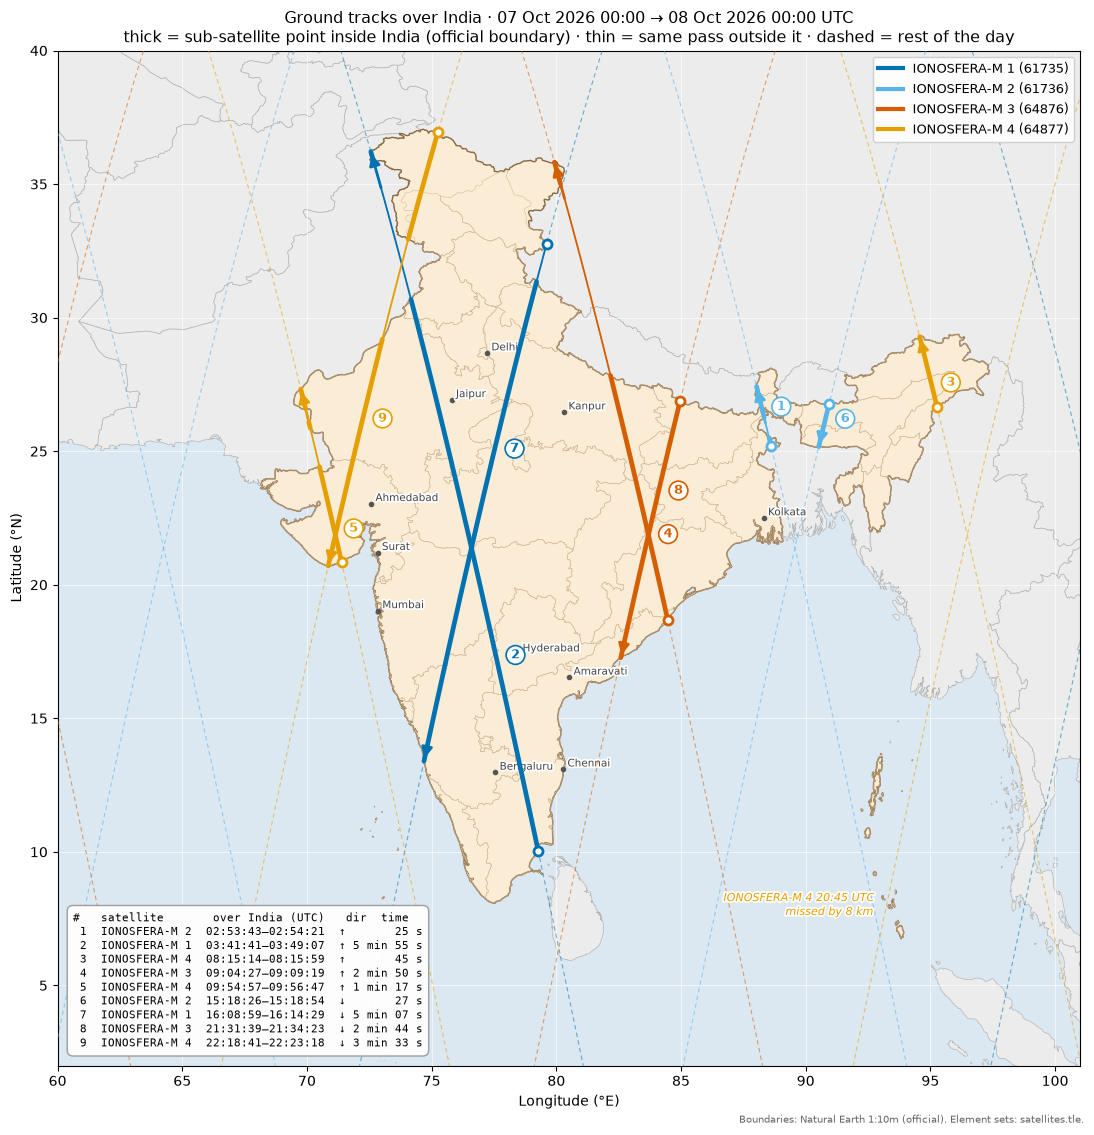

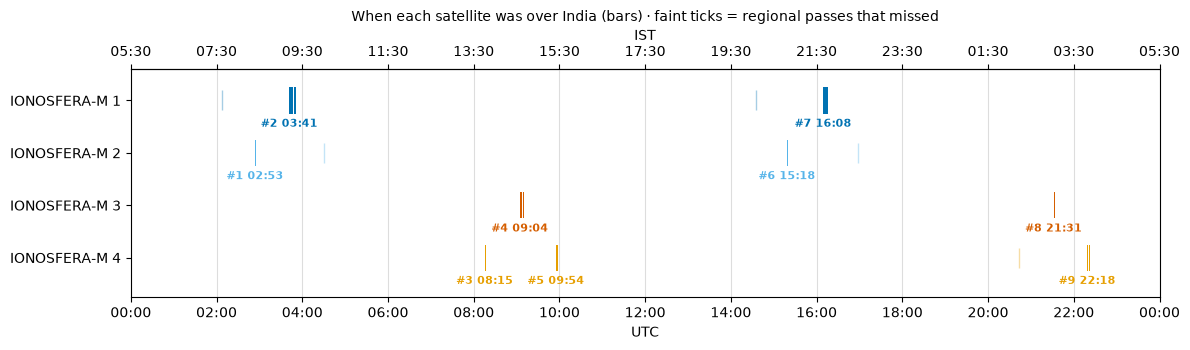

**Cross-checks** (a) independent propagation (b) independent crossing detection (c) the other boundary

,satellite,points,max horizontal diff (m),mean horizontal diff (m),max height diff (m)
0,IONOSFERA-M 1,8641,43.2,28.4,0.0
1,IONOSFERA-M 2,8641,43.2,28.4,0.0
2,IONOSFERA-M 3,8641,43.2,28.0,0.0
3,IONOSFERA-M 4,8641,43.2,28.1,0.0


Skyfield's UT1−UTC on 2026-10-07: +0.093 s -> up to 43 m of Earth rotation at the equator


,satellite,pass (UTC),stretches (main),stretches (independent),max |Δt| (s),agree
0,IONOSFERA-M 1,03:41:41,3,3,0.028,True
1,IONOSFERA-M 1,16:08:59,3,3,0.046,True
2,IONOSFERA-M 2,02:53:43,2,2,0.030,True
3,IONOSFERA-M 2,15:18:26,1,1,0.013,True
4,IONOSFERA-M 3,09:04:27,2,2,0.015,True
5,IONOSFERA-M 3,21:31:39,1,1,0.010,True
6,IONOSFERA-M 4,08:15:14,1,1,0.015,True
7,IONOSFERA-M 4,09:54:57,3,3,0.022,True
8,IONOSFERA-M 4,22:18:41,2,2,0.022,True


All entries and exits agree within 0.05 s: True
Overflights: 9 with the official boundary, 9 with the defacto boundary


,satellite,entry (official),entry (defacto),Δ entry (s),Δ exit (s),same states
0,IONOSFERA-M 1,03:41:41,03:41:41,0,-95,False
1,IONOSFERA-M 1,16:08:59,16:08:59,0,0,True
2,IONOSFERA-M 2,02:53:43,02:53:43,0,0,True
3,IONOSFERA-M 2,15:18:26,15:18:26,0,0,True
4,IONOSFERA-M 3,09:04:27,09:04:27,0,-137,False
5,IONOSFERA-M 3,21:31:39,21:31:39,0,0,True
6,IONOSFERA-M 4,08:15:14,08:15:14,0,0,True
7,IONOSFERA-M 4,09:54:57,09:54:57,0,0,True
8,IONOSFERA-M 4,22:18:41,22:19:19,38,0,False


6 of 9 overflights are identical under both boundaries.
  IONOSFERA-M 1 entering 03:41:41 UTC: entry moves 0 s, exit moves -95 s
  IONOSFERA-M 3 entering 09:04:27 UTC: entry moves 0 s, exit moves -137 s
  IONOSFERA-M 4 entering 22:18:41 UTC: entry moves 38 s, exit moves 0 s
Written to outputs\20261007T0000_20261008T0000/: ground_tracks.geojson, ground_tracks_30s.csv, india_overflights.csv, india_paths.geojson, india_states.csv, india_towns.csv, map_india_overflights.png, overflights.czml, regional_passes.csv, timeline.png


---
### All windows

,window,satellite,date (UTC),entry (UTC),exit (UTC),entry (IST),time over India,direction,states crossed
0,1,IONOSFERA-M 1,2026-10-07,03:41:41,03:49:07,09:11:41,5 min 55 s,northbound,Tamil Nadu → Andhra Pradesh → Telangana → Karnataka → Maharashtra → Madhya Pradesh → Rajasthan → Madhya Pradesh → Ra...
1,1,IONOSFERA-M 1,2026-10-07,16:08:59,16:14:29,21:38:59,5 min 07 s,southbound,Ladakh → (outside India) → Uttarakhand → Uttar Pradesh → Rajasthan → Madhya Pradesh → Maharashtra → Karnataka → Maha...
2,1,IONOSFERA-M 2,2026-10-07,02:53:43,02:54:21,08:23:43,25 s,northbound,West Bengal → (outside India) → West Bengal → Sikkim
3,1,IONOSFERA-M 2,2026-10-07,15:18:26,15:18:54,20:48:26,27 s,southbound,Assam → Meghalaya
4,1,IONOSFERA-M 3,2026-10-07,09:04:27,09:09:19,14:34:27,2 min 50 s,northbound,Andhra Pradesh → Odisha → Chhattisgarh → Uttar Pradesh → (outside India) → China-administered Aksai Chin / Shaksgam ...
5,1,IONOSFERA-M 3,2026-10-07,21:31:39,21:34:23,03:01:39,2 min 44 s,southbound,Bihar → Jharkhand → Chhattisgarh → Odisha → Andhra Pradesh
6,1,IONOSFERA-M 4,2026-10-07,08:15:14,08:15:59,13:45:14,45 s,northbound,Arunachal Pradesh → Assam → Arunachal Pradesh
7,1,IONOSFERA-M 4,2026-10-07,09:54:57,09:56:47,15:24:57,1 min 17 s,northbound,Gujarat → (outside India) → Rajasthan → (outside India) → Rajasthan
8,1,IONOSFERA-M 4,2026-10-07,22:18:41,22:23:18,03:48:41,3 min 33 s,southbound,Pakistan-administered Kashmir (claimed by India) → Jammu and Kashmir → (outside India) → Rajasthan → Gujarat


In [15]:
summary = []
for w, (start, end) in enumerate(windows, 1):
    display(Markdown(f"---\n### Window {w}: {start:%Y-%m-%d %H:%M} → {end:%Y-%m-%d %H:%M} UTC "
                     f"({start.astimezone(IST):%Y-%m-%d %H:%M} → {end.astimezone(IST):%H:%M} IST)"))
    display(set_window(start, end))
    result = analyse(india)
    show_answer(result)
    draw_map(result)
    draw_timeline(result)
    if RUN_CHECKS:
        display(Markdown("**Cross-checks** (a) independent propagation (b) independent crossing detection "
                         "(c) the other boundary"))
        check_a()
        check_b(result)
        check_c(result)
    export(result)
    ov = result["overflights"].assign(window=w)
    summary.append(ov)

summary = pd.concat(summary, ignore_index=True)
summary.to_csv(os.path.join(OUT_ROOT, "summary.csv"), index=False)
display(Markdown("---\n### All windows"))
summary[["window", "satellite", "date (UTC)", "entry (UTC)", "exit (UTC)", "entry (IST)", "time over India", "direction", "states crossed"]]

## Notes and limits

- **Accuracy.** A TLE is good to about a kilometre near its epoch, which is a fraction of a second in the crossing
  times. Accuracy falls off with distance from the epoch: watch the "epoch − window middle" column, and use element
  sets from within a day or two of each window.
- **"Over India"** means land territory including islands; territorial waters and the EEZ are not included.
- **CZML** (`overflights.czml`, one per window) loads in Cesium with
  `viewer.dataSources.add(Cesium.CzmlDataSource.load("overflights.czml"))`; each satellite turns orange while
  over India.